# Кластеризация сигналов

В некоторых веществах в результате прохождения через них заряженных частиц возникают короткие вспышки света – сцинтилляции. Вещества, излучающие свет под действием ионизирующего излучения, называют сцинтилляторами.

Сцинтилляции отличны от остальных видов свечения, образующегося во время взаимодействия частиц с веществом тем, что они возникают вследствие электронных переходов внутри так называемых центров свечения. Такими центрами свечения могут служить, например, атомы, ионы, молекулы. Каждая вспышка вызвана отдельной заряженной частицей и состоит из большого количества (10^3 − 10^6) фотонов.

При получении данных, эксперименты с которыми производились в настоящей работе, был использован сцинтилляционный детектор, на основе органических кристаллов паратерфенила. Перспективность сцинтилляторов на основе органических кристаллов паратерфенила в регистрации нейтронного излучения в присутствии гамма-фона обуславливает большое содержание атомов водорода в вышеупомянутых элементах систем детектирования. Вызвано это тем, что для регистрации нейтронов используют эффект упругого рассеяния нейтронов с ядром.

При упругом рассеянии нейтронов на ядрах, наблюдается эффект отдачи кинетической энергии. Таким образом, вещество, из которого должен быть сделан сцинтиллятор, выбирается в соответствии с тем требованием, чтобы кинетическая энергия была максимально возможной. Наибольшее значение данной энергии наблюдается для ядер водорода. Именно поэтому высокое содержание водорода в используемом сцинтилляторе играет весомую роль в процессе детектирования излучения, содержащего в себе нейтроны.

**Задача:** разделить 23 479 осциллограмм на 3 класса без учителя:

- `0` — первая физическая компонента, обычно ветка с меньшей долей хвоста, интерпретируется как gamma-like;
- `1` — вторая физическая компонента, обычно ветка с большей долей хвоста, интерпретируется как neutron-like;
- `2` — аномальные, смешанные или неидентифицируемые сигналы.


> Метки кластеров в задаче произвольны. Поэтому после кластеризации выполняется физическая интерпретация: кластер с явными шумовыми/аномальными характеристиками переводится в `2`, две основные ветки сортируются по PSD-признаку: меньший хвост → `0`, больший хвост → `1`

In [1]:
from __future__ import annotations

import itertools
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.cluster import Birch, KMeans, MiniBatchKMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score, silhouette_score)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PowerTransformer
from IPython.display import display
from sklearn.preprocessing import RobustScaler, StandardScaler


warnings.filterwarnings("ignore")

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
CUSTOM_COLORS = ["red", "blue", "green", "pink", "yellow"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=CUSTOM_COLORS)
sns.set_palette(CUSTOM_COLORS)

In [3]:
DATA_PATH = Path("/content/Run200_Wave_0_1.txt")

In [4]:
raw = pd.read_csv(DATA_PATH, sep=r"\s+", header=None, engine="python")
raw = raw.dropna(axis=1, how="all")

print("Размер исходной таблицы:", raw.shape)
metadata = raw.iloc[:, :4].copy()
metadata.columns = ["meta_0", "meta_1", "meta_2", "n_points"]

waves = raw.iloc[:, 4:].to_numpy(dtype=np.float32)

Размер исходной таблицы: (23479, 504)


In [5]:
print(f"Размер массива сигналов: {waves.shape}")
print(f"Размер metadata: {metadata.shape}")

print("Первые строки metadata:")
display(metadata.head())

print("Первые 5 сигналов, первые 10 точек:")
display(pd.DataFrame(waves[:5, :10], columns=[f"t_{i}" for i in range(10)]))

Размер массива сигналов: (23479, 500)
Размер metadata: (23479, 4)
Первые строки metadata:


,meta_0,meta_1,meta_2,n_points
0,2890276,357,113,500
1,4928764,740,359,500
2,9630204,162,499,500
3,15798632,841,123,500
4,20637296,412,348,500


Первые 5 сигналов, первые 10 точек:


,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9
0,14820.0,14823.0,14824.0,14822.0,14818.0,14820.0,14824.0,14822.0,14820.0,14820.0
1,14820.0,14822.0,14820.0,14826.0,14824.0,14822.0,14820.0,14822.0,14823.0,14821.0
2,14820.0,14820.0,14822.0,14825.0,14820.0,14824.0,14824.0,14819.0,14823.0,14824.0
3,14828.0,14822.0,14818.0,14824.0,14824.0,14822.0,14820.0,14822.0,14824.0,14820.0
4,14823.0,14815.0,14823.0,14821.0,14827.0,14820.0,14823.0,14824.0,14816.0,14821.0


Исходный файл содержит 23 479 строк. В каждой строке первые четыре столбца являются служебной информацией, а последующие 500 значений описывают форму зарегистрированного сигнала. Поэтому перед анализом данные были разделены на таблицу служебных параметров metadata и массив осциллограмм waves. Для дальнейшей кластеризации использовались только 500 точек сигнала, так как они отражают форму импульса сцинтилляционного детектора.

## 2. EDA
Цель этапа:

- проверить размерность данных;
- понять ориентацию импульса: сигнал уходит вверх или вниз относительно baseline;
- оценить baseline и шум до прихода импульса;
- визуально проверить, где расположен пик.

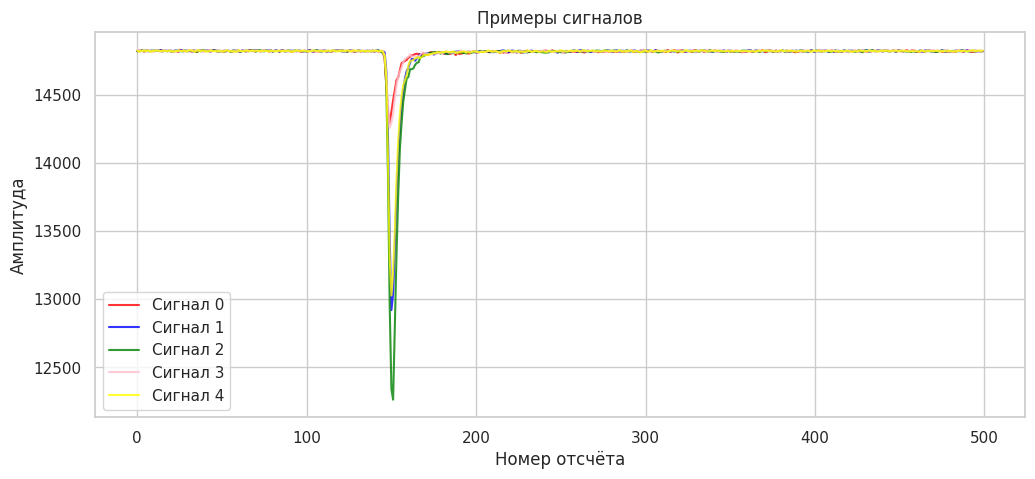

In [6]:
plt.figure(figsize=(12, 5))

for i in range(5):
    plt.plot(waves[i], alpha=0.8, label=f"Сигнал {i}")

plt.title("Примеры сигналов")
plt.xlabel("Номер отсчёта")
plt.ylabel("Амплитуда")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
def describe_array(x: np.ndarray, name: str) -> pd.DataFrame:
    flat = x.ravel()
    return pd.DataFrame(
        {
            "name": [name],
            "shape": [x.shape],
            "min": [np.nanmin(flat)],
            "q01": [np.nanquantile(flat, 0.01)],
            "median": [np.nanmedian(flat)],
            "mean": [np.nanmean(flat)],
            "q99": [np.nanquantile(flat, 0.99)],
            "max": [np.nanmax(flat)],
            "nan_count": [np.isnan(flat).sum()],
        }
    )

raw_summary = describe_array(waves, "raw_waveforms")
display(raw_summary)

n_signals, n_points = waves.shape
baseline_window = min(100, max(20, n_points // 5))
baseline_raw = np.median(waves[:, :baseline_window], axis=1)
noise_raw = np.std(waves[:, :baseline_window], axis=1)

eda_baseline = pd.DataFrame(
    {
        "baseline_median": baseline_raw,
        "baseline_noise_std": noise_raw,
        "raw_min": waves.min(axis=1),
        "raw_max": waves.max(axis=1),
        "raw_argmin": waves.argmin(axis=1),
        "raw_argmax": waves.argmax(axis=1),
    }
)

display(eda_baseline.describe().T)

negative_depth = np.median(baseline_raw - waves.min(axis=1))
positive_height = np.median(waves.max(axis=1) - baseline_raw)
orientation = "negative" if negative_depth >= positive_height else "positive"
print(f"Ориентация импульса: {orientation}")
print(f"Медианный уход вниз: {negative_depth:.2f}; медианный уход вверх: {positive_height:.2f}")

,name,shape,min,q01,median,mean,q99,max,nan_count
0,raw_waveforms,"(23479, 500)",0.0,14335.0,14822.0,14796.681641,14829.0,14838.0,0


,count,mean,std,min,25%,50%,75%,max
baseline_median,23479.0,14823.035156,4.060397,14819.000000,14823.000000,14823.000000,14824.00000,14827.000000
baseline_noise_std,23479.0,2.697836,0.193979,1.951282,2.570399,2.694736,2.81929,10.943295
raw_min,23479.0,12987.862305,2389.312500,0.000000,12508.000000,14010.000000,14515.00000,14719.000000
raw_max,23479.0,14830.710938,1.774255,14827.000000,14830.000000,14831.000000,14832.00000,14838.000000
raw_argmin,23479.0,149.628604,2.489996,145.000000,149.000000,150.000000,151.00000,472.000000
raw_argmax,23479.0,198.072874,165.293308,0.000000,50.000000,123.000000,360.00000,499.000000


Ориентация импульса: negative
Медианный уход вниз: 813.00; медианный уход вверх: 8.00


Медианное значение всех точек осциллограмм составляет примерно **14822 ADC**. Это соответствует уровню базовой линии до прихода импульса. Среднее значение равно примерно **14796.7 ADC** и оказывается ниже медианы, потому что во временном окне присутствуют отрицательные импульсы, уменьшающие среднее значение.

Базовая линия находится примерно в диапазоне **14819–14827 ADC**, то есть уровень baseline достаточно стабилен. Шум на baseline также невысокий: среднее значение `baseline_noise_std` составляет около **2.7 ADC**. При этом максимальное значение шума достигает примерно **10.94 ADC**, что указывает на наличие отдельных более шумных событий. Такие сигналы не удаляются, так как по условию задачи один из кластеров должен отражать аномальные или плохо идентифицируемые события.

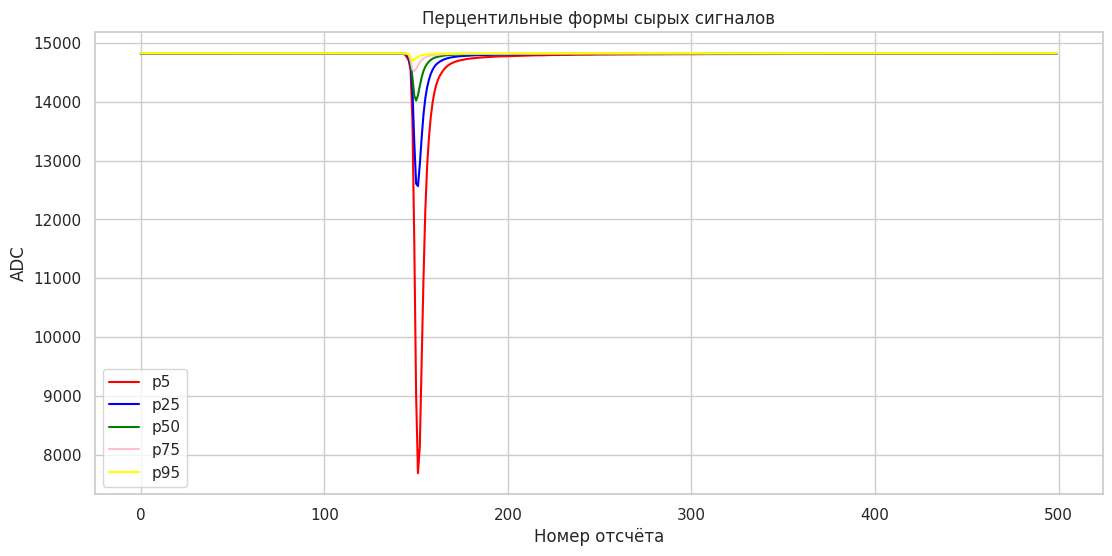

In [8]:
# перцентили по всем сигналам
wave_percentiles = np.percentile(waves, [5, 25, 50, 75, 95], axis=0)
plt.figure(figsize=(13, 6))
for q, curve in zip([5, 25, 50, 75, 95], wave_percentiles):
    plt.plot(curve, label=f"p{q}")
plt.title("Перцентильные формы сырых сигналов")
plt.xlabel("Номер отсчёта")
plt.ylabel("ADC")
plt.legend()
plt.show()

### Выводы

Важным результатом EDA является определение ориентации импульса. Сравнение отклонений относительно baseline показало, что медианный уход сигнала вниз составляет около **813 ADC**, а медианный уход вверх — только около **8 ADC**. Следовательно, импульсы имеют **отрицательную ориентацию**: при регистрации события значение сигнала резко уменьшается относительно базовой линии.

Поэтому перед извлечением признаков сигнал необходимо инвертировать по формуле:

`signal = baseline - wave`

После такой операции физический импульс становится положительным, и для него можно корректно рассчитывать амплитуду, площадь, ширину и PSD-признаки.

Анализ минимальных значений показал, что `raw_min` достигает **0**. Такое значение нетипично на фоне стабильной базовой линии и может соответствовать техническому сбою, насыщению измерительной системы или аномальному событию. Положение минимума также в основном стабильно: медианное значение `raw_argmin` равно примерно **150**, то есть большинство импульсов достигают максимального отрицательного отклонения около 150-го отсчёта. Однако максимальное значение `raw_argmin` равно **472**, что указывает на редкие события с поздним положением пика.

Таким образом, анализ показал, что данные загружены корректно, сигналы имеют стабильную базовую линию и отрицательную ориентацию импульса. Для дальнейшей обработки необходимо перейти от сырых осциллограмм к положительным импульсам и извлечь физически интерпретируемые признаки: амплитуду, площадь, долю хвоста, PSD ratio, положение пика, ширину импульса и признаки возможной аномальности.

## 3. Feature Engineering

Сырые 500 точек не подаются напрямую в простую кластеризацию: масштабы признаков разные, а физическая структура лучше видна через параметры формы импульса. Поэтому здесь строятся две группы признаков.

Первая группа — общие признаки формы импульса: амплитуда, площадь, шум, SNR, положение пика, ширина.

Вторая группа — PSD-признаки. Это самые важные признаки для разделения gamma и neutron, так как они показывают, какая доля площади сигнала находится в хвосте импульса.

In [9]:
def make_positive_pulses(waves: np.ndarray, baseline_window: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray, str]:
    baseline = np.median(waves[:, :baseline_window], axis=1)
    noise = np.std(waves[:, :baseline_window], axis=1)

    neg_depth = np.median(baseline - waves.min(axis=1))
    pos_height = np.median(waves.max(axis=1) - baseline)

    if neg_depth >= pos_height:
        pulses = baseline[:, None] - waves
        orientation = "negative"
    else:
        pulses = waves - baseline[:, None]
        orientation = "positive"

    pulses = np.where(pulses > 0, pulses, 0).astype(np.float32)
    return pulses, baseline.astype(np.float32), noise.astype(np.float32), orientation

In [10]:
def gate_sum(sig: np.ndarray, left: int, right: int) -> float:
    left = max(0, int(left))
    right = min(len(sig), int(right))
    if right <= left:
        return 0.0
    return float(sig[left:right].sum())

In [11]:
def extract_features(waves: np.ndarray, baseline_window: int = 100) -> Tuple[pd.DataFrame, np.ndarray]:
    pulses, baseline, baseline_noise, orientation = make_positive_pulses(waves, baseline_window)
    n_rows, n_cols = pulses.shape
    rows = []

    for i in range(n_rows):
        sig = pulses[i]
        amp = float(sig.max())
        t_peak = int(sig.argmax())
        noise = float(baseline_noise[i])
        start_threshold = max(5.0 * noise, 0.05 * amp)

        above = np.flatnonzero(sig > start_threshold)
        if above.size:
            t_start = int(above[0])
            t_end = int(above[-1])
        else:
            t_start = max(0, t_peak - 5)
            t_end = t_peak

        s0 = max(0, t_start)
        s30 = min(n_cols, s0 + 30)
        s60 = min(n_cols, s0 + 60)
        s180 = min(n_cols, s0 + 180)

        area_full = float(sig.sum())
        area_30 = float(sig[s0:s30].sum())
        area_60 = float(sig[s0:s60].sum())
        area_180 = float(sig[s0:s180].sum())
        tail_after_30 = float(sig[s30:s180].sum())

        p_left = t_peak - 5
        q_total_120 = gate_sum(sig, p_left, t_peak + 120)
        q_total_160 = gate_sum(sig, p_left, t_peak + 160)
        q_total_200 = gate_sum(sig, p_left, t_peak + 200)

        q_prompt_20 = gate_sum(sig, p_left, t_peak + 20)
        q_prompt_30 = gate_sum(sig, p_left, t_peak + 30)
        q_prompt_40 = gate_sum(sig, p_left, t_peak + 40)
        q_prompt_50 = gate_sum(sig, p_left, t_peak + 50)

        psd_20_160 = (q_total_160 - q_prompt_20) / q_total_160 if q_total_160 > 0 else 0.0
        psd_30_160 = (q_total_160 - q_prompt_30) / q_total_160 if q_total_160 > 0 else 0.0
        psd_40_160 = (q_total_160 - q_prompt_40) / q_total_160 if q_total_160 > 0 else 0.0
        psd_50_200 = (q_total_200 - q_prompt_50) / q_total_200 if q_total_200 > 0 else 0.0

        half = 0.5 * amp
        above_half = np.flatnonzero(sig >= half) if amp > 0 else np.array([], dtype=int)
        fwhm = int(above_half[-1] - above_half[0] + 1) if above_half.size else 0

        pre_peak = sig[:t_peak + 1]
        idx10 = np.flatnonzero(pre_peak >= 0.1 * amp) if amp > 0 else np.array([], dtype=int)
        idx90 = np.flatnonzero(pre_peak >= 0.9 * amp) if amp > 0 else np.array([], dtype=int)
        rise_10_90 = int(idx90[0] - idx10[0]) if idx10.size and idx90.size else 0

        post_peak = sig[t_peak:]
        below_e = np.flatnonzero(post_peak <= amp / np.e) if amp > 0 else np.array([], dtype=int)
        decay_e = int(below_e[0]) if below_e.size else int(n_cols - t_peak - 1)

        rows.append({
            "baseline": float(baseline[i]),
            "baseline_noise": noise,
            "amplitude": amp,
            "log_amplitude": np.log1p(amp),
            "snr": amp / (noise + 1e-9),
            "area_full": area_full,
            "area_30": area_30,
            "area_60": area_60,
            "area_180": area_180,
            "log_area_180": np.log1p(area_180),
            "tail_ratio_start30": tail_after_30 / area_180 if area_180 > 0 else 0.0,
            "prompt_ratio_30": area_30 / area_180 if area_180 > 0 else 0.0,
            "medium_ratio_60": area_60 / area_180 if area_180 > 0 else 0.0,
            "q_total_120": q_total_120,
            "q_total_160": q_total_160,
            "q_total_200": q_total_200,
            "log_q_total_160": np.log1p(q_total_160),
            "psd_20_160": psd_20_160,
            "psd_30_160": psd_30_160,
            "psd_40_160": psd_40_160,
            "psd_50_200": psd_50_200,
            "t_start": t_start,
            "t_peak": t_peak,
            "t_end": t_end,
            "fwhm": fwhm,
            "rise_10_90": rise_10_90,
            "decay_e": decay_e,
            "zero_count": int(np.sum(waves[i] == 0)),
            "has_zero": int(np.any(waves[i] == 0)),
            "late_peak": int(t_peak > 250),
        })

    features = pd.DataFrame(rows)
    features.insert(0, "index", np.arange(len(features)))
    features["orientation"] = orientation
    features = features.replace([np.inf, -np.inf], np.nan)
    return features, pulses

In [12]:
features, pulses = extract_features(waves, baseline_window=baseline_window)

print("Размер таблицы признаков:", features.shape)
display(features.head())
display(features.describe(include="all").T)

num_features = features.select_dtypes(include=[np.number]).drop(columns=["index"], errors="ignore")
quality_report = pd.DataFrame({
    "missing_count": num_features.isna().sum(),
    "missing_share": num_features.isna().mean(),
    "n_unique": num_features.nunique(dropna=True),
}).sort_values(["missing_share", "n_unique"], ascending=[False, True])

display(quality_report)
print("Константные признаки:", quality_report.query("n_unique <= 1").index.tolist())
print("Дубликаты feature-векторов:", num_features.duplicated().sum())

Размер таблицы признаков: (23479, 32)


,index,baseline,baseline_noise,amplitude,log_amplitude,snr,area_full,area_30,area_60,area_180,log_area_180,tail_ratio_start30,prompt_ratio_30,medium_ratio_60,q_total_120,q_total_160,q_total_200,log_q_total_160,psd_20_160,psd_30_160,psd_40_160,psd_50_200,t_start,t_peak,t_end,fwhm,rise_10_90,decay_e,zero_count,has_zero,late_peak,orientation
0,0,14820.5,2.777246,529.5,6.273820,190.656499,4767.0,3612.0,3979.0,4378.5,8.384690,0.175060,0.824940,0.908759,4252.0,4346.0,4414.0,8.377241,0.195237,0.160492,0.121376,0.105460,146,149,188,5,3,5,0,0,0,negative
1,1,14823.0,2.658778,1902.0,7.551187,715.366309,12836.0,11478.0,11784.0,12213.0,9.410338,0.060182,0.939818,0.964873,12099.0,12179.0,12279.0,9.407551,0.068561,0.052796,0.042122,0.042919,147,150,160,5,2,5,0,0,0,negative
2,2,14822.0,2.488694,2558.0,7.847372,1027.848459,17290.0,15939.0,16269.0,16707.0,9.723643,0.045969,0.954031,0.973783,16631.0,16725.0,16810.0,9.724720,0.049925,0.041674,0.032825,0.031053,147,151,163,5,3,4,0,0,0,negative
3,3,14823.0,2.825315,565.0,6.338594,199.977668,5090.0,3913.0,4197.0,4610.0,8.436200,0.151193,0.848807,0.910412,4477.0,4583.0,4648.0,8.430327,0.178922,0.133973,0.105608,0.107788,146,149,167,5,2,5,0,0,0,negative
4,4,14821.5,2.764977,1793.5,7.492482,648.649050,12035.5,11087.0,11318.0,11613.5,9.360010,0.045335,0.954665,0.974555,11527.0,11614.0,11674.0,9.360053,0.056268,0.039306,0.032676,0.031395,147,150,160,5,3,5,0,0,0,negative


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,23479.0,NaN,NaN,NaN,11739.0,6777.947821,0.0,5869.5,11739.0,17608.5,23478.0
baseline,23479.0,NaN,NaN,NaN,14823.035968,0.867276,14819.0,14823.0,14823.0,14824.0,14827.0
baseline_noise,23479.0,NaN,NaN,NaN,2.697836,0.193979,1.951282,2.570399,2.694736,2.81929,10.943295
amplitude,23479.0,NaN,NaN,NaN,1835.174177,2389.299361,104.0,308.0,813.0,2315.0,14825.0
log_amplitude,23479.0,NaN,NaN,NaN,6.782458,1.23243,4.65396,5.733341,6.70196,7.747597,9.604138
snr,23479.0,NaN,NaN,NaN,683.969231,894.480676,35.692849,114.721994,301.307267,861.697327,5857.69164
area_full,23479.0,NaN,NaN,NaN,13535.616785,16029.064089,948.0,2909.0,6646.0,17634.0,113304.0
area_30,23479.0,NaN,NaN,NaN,11836.530474,14871.328018,625.0,2116.5,5454.0,15260.0,107057.0
area_60,23479.0,NaN,NaN,NaN,12343.204481,15331.282442,642.0,2257.0,5754.0,16047.0,109458.0
area_180,23479.0,NaN,NaN,NaN,12956.938796,15800.890873,738.0,2497.5,6160.0,16938.0,111828.0


,missing_count,missing_share,n_unique
has_zero,0,0.0,2
late_peak,0,0.0,2
zero_count,0,0.0,4
rise_10_90,0,0.0,6
decay_e,0,0.0,8
t_peak,0,0.0,9
fwhm,0,0.0,9
t_start,0,0.0,10
baseline,0,0.0,16
t_end,0,0.0,241


Константные признаки: []
Дубликаты feature-векторов: 0


Проверка качества признаков показала, что сформированный набор данных не содержит пропущенных значений. Для всех признаков missing_count равен 0, а missing_share составляет 0.0. Это означает, что при извлечении признаков не возникло ошибок, связанных с неопределёнными значениями, делением на ноль или невозможностью рассчитать отдельные характеристики сигнала.

Константные признаки отсутствуют. Это важно, поскольку признаки, принимающие одно и то же значение для всех объектов, не несут информации для кластеризации и могли бы ухудшить качество модели. В данном случае каждый рассчитанный числовой признак имеет хотя бы несколько уникальных значений.

Бинарные признаки has_zero и late_peak имеют по два уникальных значения, что соответствует их смыслу. Они используются как индикаторы редких событий: наличия нулевых значений в сигнале и позднего положения пика. Несмотря на малое число уникальных значений, такие признаки не являются ошибочными, так как отражают потенциальные аномалии.

Временные признаки имеют меньше уникальных значений, чем амплитудные и интегральные признаки. Например, rise_10_90 имеет 6 уникальных значений, decay_e — 8, t_peak и fwhm — по 9. Это объясняется дискретной природой осциллограмм: временные параметры определяются по номерам отсчётов и поэтому не могут принимать непрерывный набор значений.

Амплитудные и интегральные признаки обладают высокой вариативностью. Например, amplitude и log_amplitude имеют по 6945 уникальных значений, q_total_160 и log_q_total_160 — по 14741, area_180 и log_area_180 — по 14786. Это говорит о том, что признаки достаточно подробно отражают различия между сигналами.

Особенно высокую вариативность имеют PSD-признаки и отношения площадей. Признаки psd_20_160, psd_30_160, psd_40_160, psd_50_200, tail_ratio_start30, prompt_ratio_30 и medium_ratio_60 имеют более 23 тысяч уникальных значений. Это почти соответствует общему количеству сигналов, поэтому такие признаки можно считать наиболее информативными для разделения сигналов по форме импульса.

Признак snr имеет 23467 уникальных значений, что также указывает на его высокую информативность. Он отражает отношение амплитуды сигнала к уровню шума baseline и может быть полезен как для разделения основных типов сигналов, так и для выявления нетипичных событий.

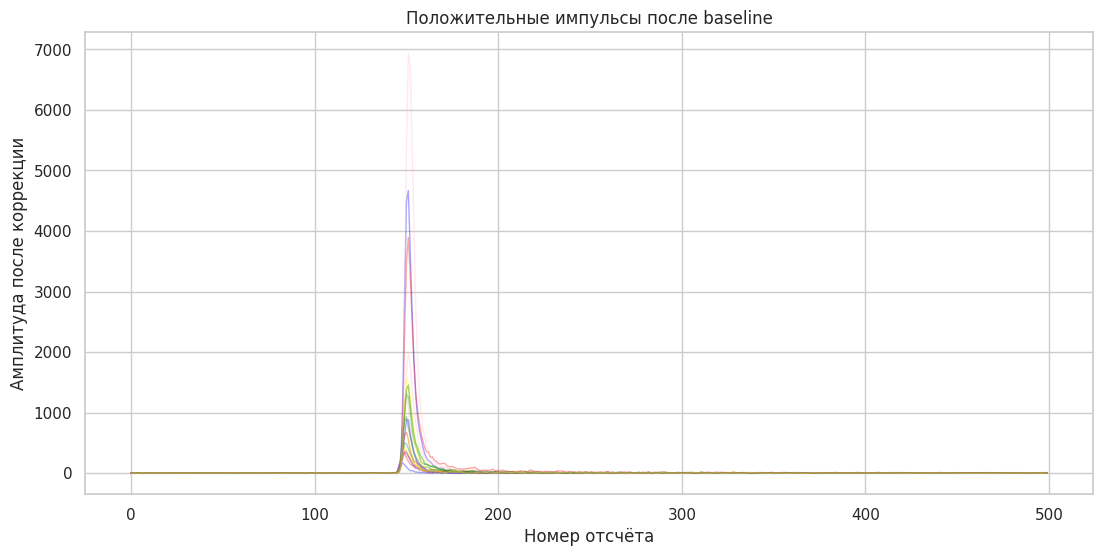

In [13]:
# график нескольких инвертированных положительных импульсов
sample_size = min(80, n_signals)
sample_idx = np.random.default_rng(RANDOM_STATE).choice(n_signals, size=sample_size, replace=False)

plt.figure(figsize=(13, 6))
for idx in sample_idx[:20]:
    plt.plot(pulses[idx], alpha=0.35, linewidth=1)
plt.title("Положительные импульсы после baseline")
plt.xlabel("Номер отсчёта")
plt.ylabel("Амплитуда после коррекции")
plt.show()

### Выводы

После обработки была получена таблица `features` размером **23479 × 32**. В неё входят 30 числовых признаков, служебный столбец `index`.

Перед извлечением признаков была выполнена проверка ориентации импульсов. Так как импульсы в исходных данных направлены вниз относительно baseline, они были инвертированы. В результате информативная часть сигнала стала положительной, что позволило корректно рассчитать амплитуду, площадь, временные параметры и PSD-признаки.

Количество дубликатов feature-векторов равно 0. Это означает, что после преобразования в пространство признаков каждый сигнал остаётся уникальным объектом. Следовательно, в данных нет повторяющихся строк, которые могли бы искусственно повлиять на работу алгоритмов кластеризации.

Таким образом, этап Feature Engineering выполнен корректно: полученные признаки описывают baseline, шум, амплитуду, площадь, форму хвоста, временное положение пика, ширину импульса и потенциальные аномалии. Именно эти признаки используются на следующих этапах для анализа структуры данных и построения финального submission.

## 4. EDA сгенерированных признаков

Ключевой график для задачи — PSD vs Energy: по оси X берём энергию/интеграл, по оси Y долю хвоста. Если данные хорошо разделимы, должны проявиться две основные ветки и облако аномалий/шума.

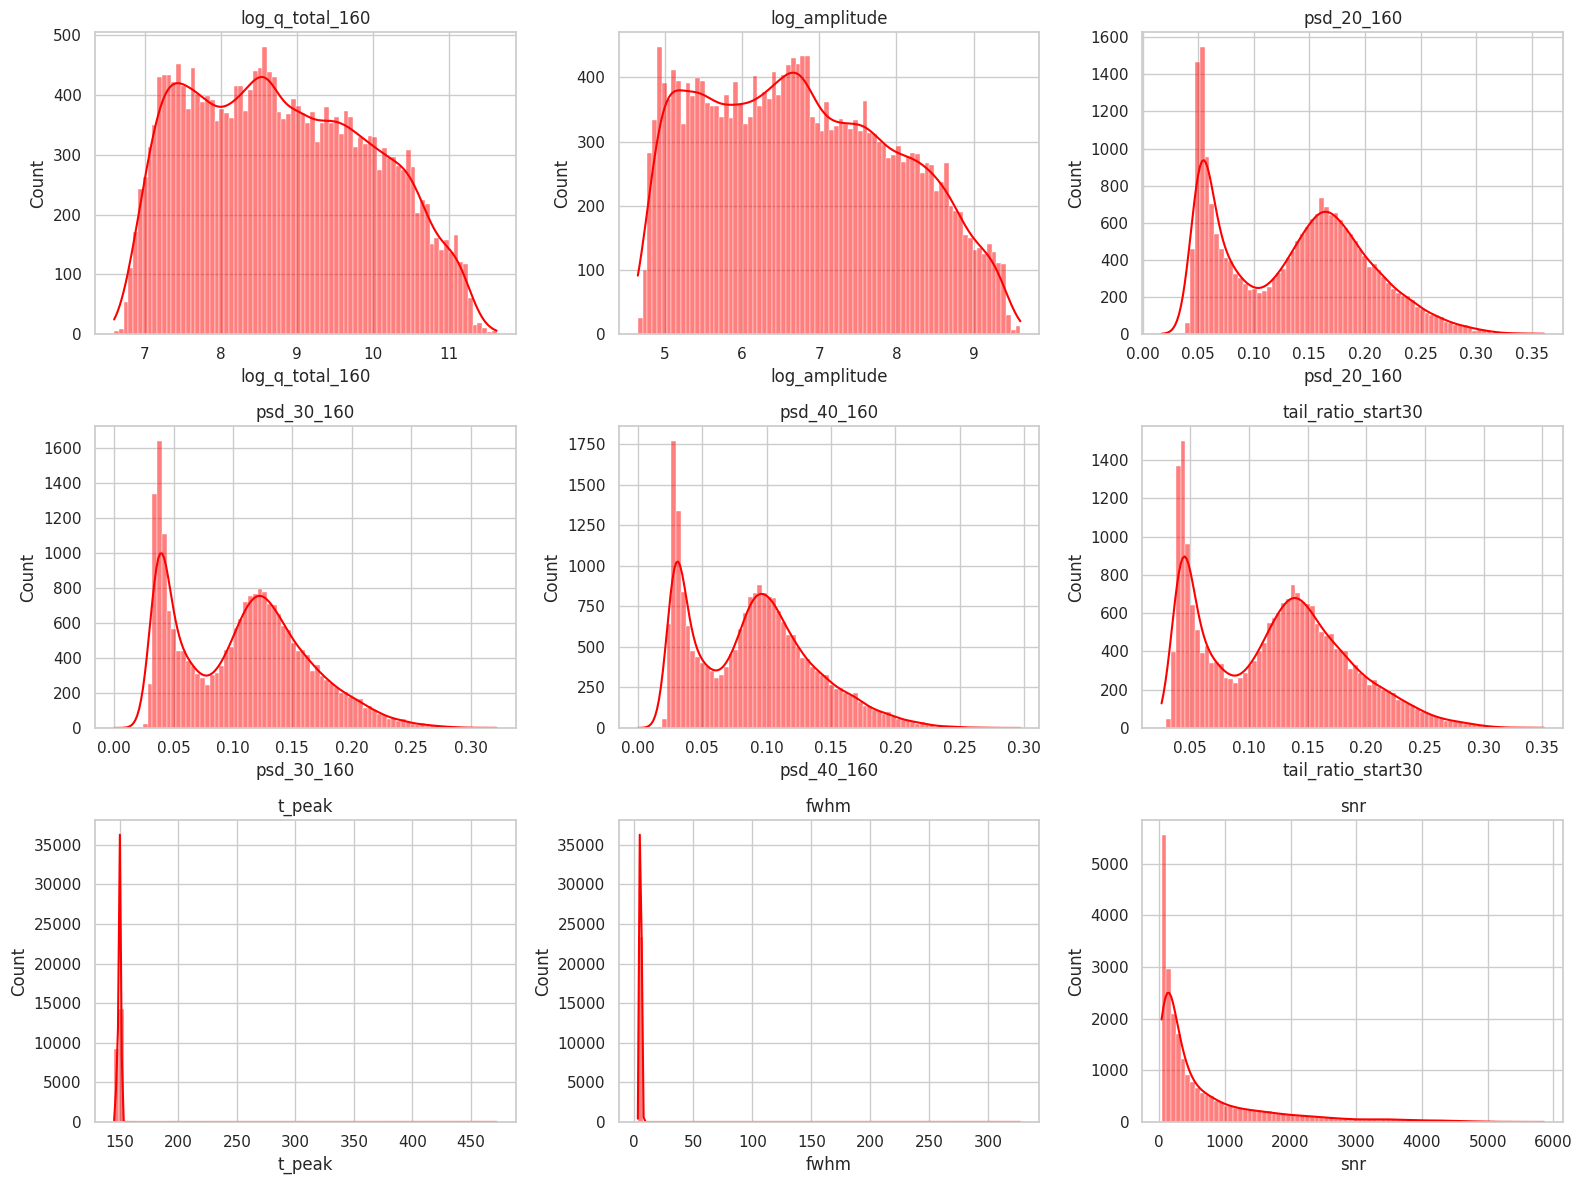

In [14]:
plot_cols = [
    "log_q_total_160", "log_amplitude", "psd_20_160", "psd_30_160",
    "psd_40_160", "tail_ratio_start30", "t_peak", "fwhm", "snr"
]
plot_cols = [c for c in plot_cols if c in features.columns]

n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).ravel()

for ax, col in zip(axes, plot_cols):
    sns.histplot(features[col], bins=80, kde=True, ax=ax)
    ax.set_title(col)

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

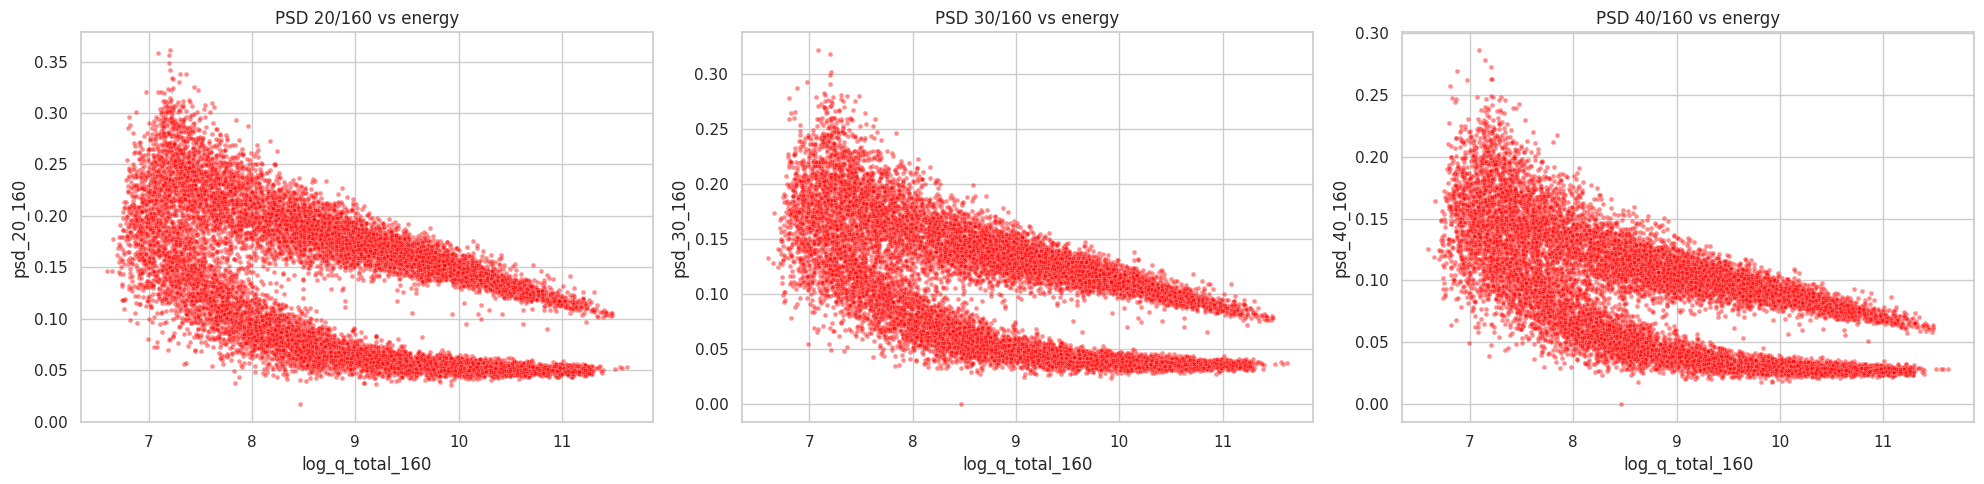

In [15]:
scatter_df = features.sample(n=min(14000, len(features)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(data=scatter_df, x="log_q_total_160", y="psd_20_160", s=12, alpha=0.45, ax=axes[0])
axes[0].set_title("PSD 20/160 vs energy")

sns.scatterplot(data=scatter_df, x="log_q_total_160", y="psd_30_160", s=12, alpha=0.45, ax=axes[1])
axes[1].set_title("PSD 30/160 vs energy")

sns.scatterplot(data=scatter_df, x="log_q_total_160", y="psd_40_160", s=12, alpha=0.45, ax=axes[2])
axes[2].set_title("PSD 40/160 vs energy")

plt.tight_layout()
plt.show()

В итоговой матрице остались признаки, описывающие основные свойства сигналов: baseline, шум, амплитуду, отношение сигнал/шум, частичные и полные площади импульса, PSD-признаки, временное положение начала и пика, ширину импульса и признаки возможной аномальности.

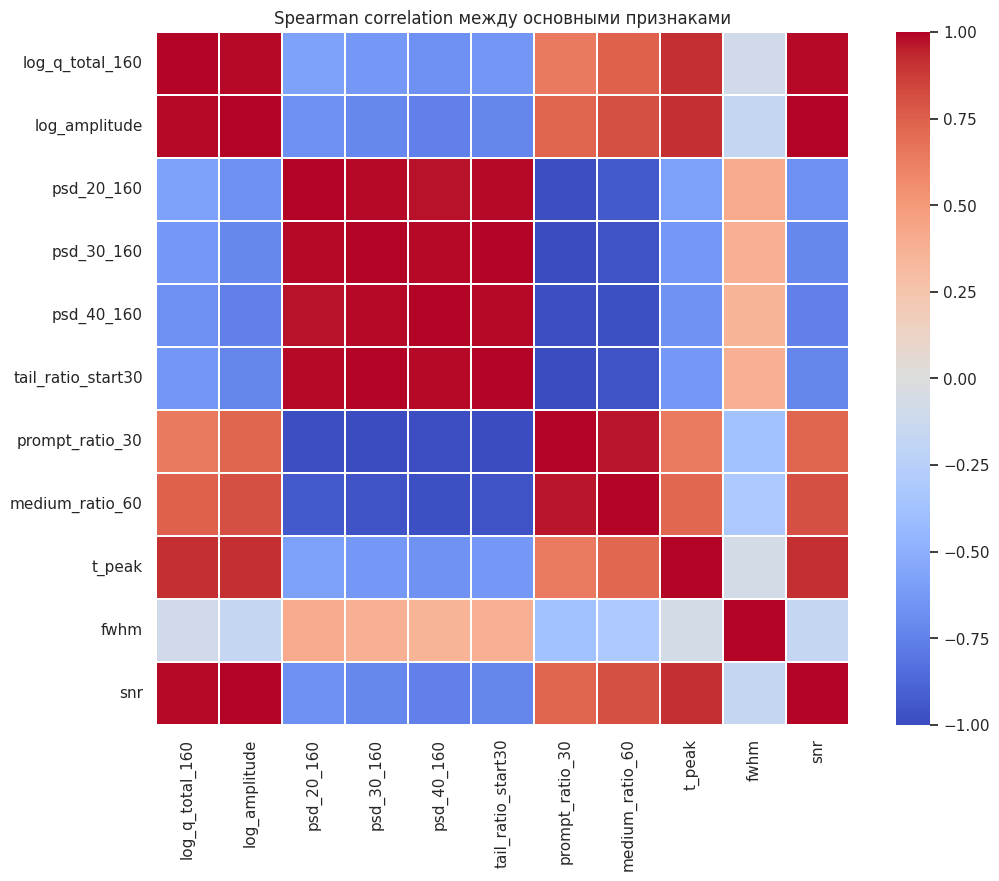

In [16]:
corr_cols = [
    'log_q_total_160', 'log_amplitude', 'psd_20_160', 'psd_30_160', 'psd_40_160',
    'tail_ratio_start30', 'prompt_ratio_30', 'medium_ratio_60', 't_peak', 'fwhm', 'snr'
]
corr_cols = [c for c in corr_cols if c in features.columns]

corr = features[corr_cols].corr(method='spearman')
plt.figure(figsize=(12, 9))
sns.heatmap(corr, center=0, cmap='coolwarm', linewidths=0.2, square=True)
plt.title('Spearman correlation между основными признаками')
plt.show()

Наиболее важными для разделения двух физических ветвей являются признаки формы хвоста: `psd_20_160`, `psd_30_160`, `psd_40_160`, `psd_50_200`, `tail_ratio_start30`, `prompt_ratio_30` и `medium_ratio_60`. Они отражают различия в форме затухания импульса, поэтому физически значимы для задачи pulse shape discrimination.

Доля объяснённой дисперсии PCA:
PC1: 0.4251
PC2: 0.3025
Суммарно: 0.7276


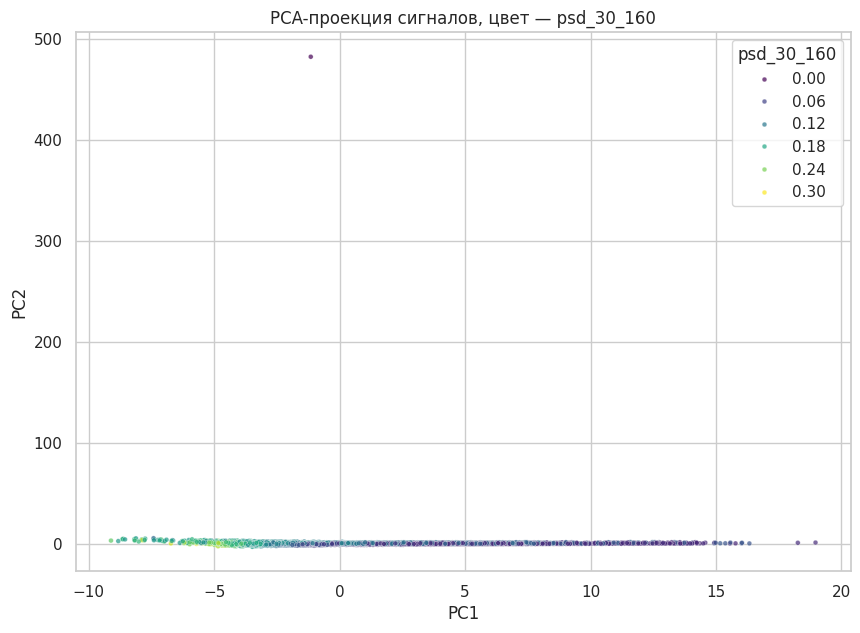

In [17]:
X = (
    features
    .select_dtypes(include=[np.number])
    .drop(columns=["index"], errors="ignore")
    .copy()
)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Доля объяснённой дисперсии PCA:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Суммарно: {pca.explained_variance_ratio_.sum():.4f}")

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "psd_30_160": features["psd_30_160"].values,
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df.sample(min(8000, len(pca_df)), random_state=RANDOM_STATE),
    x="PC1",
    y="PC2",
    hue="psd_30_160",
    palette="viridis",
    s=12,
    alpha=0.7,
)
plt.title("PCA-проекция сигналов, цвет — psd_30_160")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="psd_30_160")
plt.show()

,count,share
eda_obvious_outlier,,
False,21633,0.921377
True,1846,0.078623


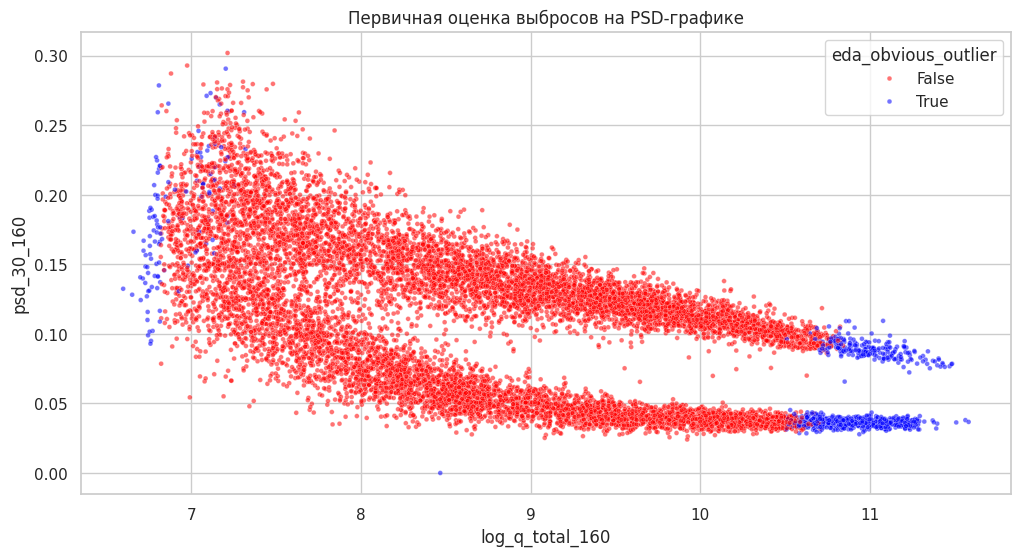

In [18]:
def robust_z_scores(df: pd.DataFrame, cols: Iterable[str]) -> pd.DataFrame:
    z = pd.DataFrame(index=df.index)

    for col in cols:
        med = df[col].median()
        mad = np.median(np.abs(df[col] - med))
        scale = 1.4826 * mad if mad > 0 else df[col].std()

        if scale == 0 or np.isnan(scale):
            z[col] = 0.0
        else:
            z[col] = np.abs((df[col] - med) / scale)

    return z


outlier_cols = [
    "log_q_total_160",
    "log_amplitude",
    "psd_30_160",
    "t_peak",
    "fwhm",
    "snr",
]

outlier_cols = [c for c in outlier_cols if c in features.columns]

robust_z = robust_z_scores(features, outlier_cols)

features["robust_outlier_score"] = robust_z.max(axis=1)

features["eda_obvious_outlier"] = (
    (features["q_total_160"] <= features["q_total_160"].quantile(0.005))
    | (features["amplitude"] <= features["amplitude"].quantile(0.005))
    | (features["robust_outlier_score"] > 6)
)

outlier_summary = (
    features["eda_obvious_outlier"]
    .value_counts(normalize=False)
    .rename("count")
    .to_frame()
)

outlier_summary["share"] = outlier_summary["count"] / len(features)

display(outlier_summary)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=features.sample(n=min(12000, len(features)), random_state=RANDOM_STATE),
    x="log_q_total_160",
    y="psd_30_160",
    hue="eda_obvious_outlier",
    s=12,
    alpha=0.55,
)
plt.title("Первичная оценка выбросов на PSD-графике")
plt.xlabel("log_q_total_160")
plt.ylabel("psd_30_160")
plt.show()

### Выводы

1. Для разделения двух основных физических ветвей наиболее важен PSD-график: `psd_30_160` против `log_q_total_160` или `log_amplitude`.
2. Для выделения аномальных событий полезны низкая энергия, низкая амплитуда, нестандартное положение пика, высокий шум baseline и нетипичная ширина импульса.
3. Амплитудные и интегральные признаки сильно связаны между собой, поэтому для финального решения используются компактные наборы признаков и физически интерпретируемая PSD-постобработка.

PCA используется здесь только как инструмент визуализации и проверки структуры признаков.

## 5. Подготовка матриц признаков

Используются несколько наборов признаков:

- `core_psd`: компактный набор для физического разделения;
- `extended_shape`: PSD и временные признаки формы;
- `anomaly_focused`: признаки, полезные для выделения шума и выбросов.

Перед кластеризацией выполняются:

- imputing пропусков медианой;
- `PowerTransformer`, если применим;
- `RobustScaler`, устойчивый к выбросам.

In [19]:
FEATURE_SETS: Dict[str, List[str]] = {
    "core_psd": [
        "log_q_total_160",
        "log_amplitude",
        "psd_20_160",
        "psd_30_160",
        "psd_40_160",
    ],

    "extended_shape": [
        "log_q_total_160",
        "log_amplitude",
        "tail_ratio_start30",
        "psd_20_160",
        "psd_30_160",
        "psd_40_160",
        "prompt_ratio_30",
        "medium_ratio_60",
        "t_peak",
        "fwhm",
        "rise_10_90",
        "decay_e",
        "baseline_noise",
        "snr",
    ],

    "anomaly_focused": [
        "log_q_total_160",
        "log_amplitude",
        "psd_30_160",
        "t_start",
        "t_peak",
        "t_end",
        "fwhm",
        "baseline_noise",
        "snr",
        "zero_count",
        "has_zero",
        "late_peak",
        "robust_outlier_score",
    ],
}

In [20]:
for name, cols in FEATURE_SETS.items():
    clean_cols = [c for c in cols if c in features.columns and features[c].nunique(dropna=True) > 1]
    FEATURE_SETS[name] = clean_cols
    print(f"{name}: {clean_cols}")


def build_scaled_matrix(
    feature_df: pd.DataFrame,
    columns: List[str],
) -> Tuple[np.ndarray, List[str], Dict[str, object]]:
    """Готовит scaled matrix для sklearn-кластеризации."""
    x_df = feature_df[columns].replace([np.inf, -np.inf], np.nan).copy()
    imputer = SimpleImputer(strategy="median")
    x_imp = imputer.fit_transform(x_df)

    variances = np.nanvar(x_imp, axis=0)
    keep_mask = variances > 1e-12
    kept_columns = [col for col, keep in zip(columns, keep_mask) if keep]
    x_imp = x_imp[:, keep_mask]

    try:
        power = PowerTransformer(method="yeo-johnson", standardize=False)
        x_trans = power.fit_transform(x_imp)
        power_used = True
    except Exception:
        power = None
        x_trans = x_imp
        power_used = False

    scaler = RobustScaler()
    x_scaled = scaler.fit_transform(x_trans)

    transformers = {
        "imputer": imputer,
        "power": power,
        "power_used": power_used,
        "scaler": scaler,
        "kept_columns": kept_columns,
    }
    return x_scaled, kept_columns, transformers


scaled_matrices: Dict[str, np.ndarray] = {}
kept_features: Dict[str, List[str]] = {}
transformers: Dict[str, Dict[str, object]] = {}

for set_name, cols in FEATURE_SETS.items():
    x_scaled, cols_kept, tr = build_scaled_matrix(features, cols)
    scaled_matrices[set_name] = x_scaled
    kept_features[set_name] = cols_kept
    transformers[set_name] = tr
    print(f"{set_name}: matrix={x_scaled.shape}, power_used={tr['power_used']}")

core_psd: ['log_q_total_160', 'log_amplitude', 'psd_20_160', 'psd_30_160', 'psd_40_160']
extended_shape: ['log_q_total_160', 'log_amplitude', 'tail_ratio_start30', 'psd_20_160', 'psd_30_160', 'psd_40_160', 'prompt_ratio_30', 'medium_ratio_60', 't_peak', 'fwhm', 'rise_10_90', 'decay_e', 'baseline_noise', 'snr']
anomaly_focused: ['log_q_total_160', 'log_amplitude', 'psd_30_160', 't_start', 't_peak', 't_end', 'fwhm', 'baseline_noise', 'snr', 'zero_count', 'has_zero', 'late_peak', 'robust_outlier_score']
core_psd: matrix=(23479, 5), power_used=True
extended_shape: matrix=(23479, 14), power_used=True
anomaly_focused: matrix=(23479, 13), power_used=True


### Выводы

После базовой подготовки были сформированы три признаковых пространства для сравнения моделей кластеризации.

Первый набор, `core_psd`, содержит наиболее физически значимые признаки: `log_q_total_160`, `log_amplitude`, `psd_20_160`, `psd_30_160` и `psd_40_160`. Он напрямую связан с pulse shape discrimination и позволяет проверить, насколько хорошо энергетические признаки и доля хвоста разделяют основные ветви сигналов.

Второй набор, `extended_shape`, дополнительно включает временные признаки и отношения площадей: `tail_ratio_start30`, `prompt_ratio_30`, `medium_ratio_60`, `t_peak`, `fwhm`, `rise_10_90`, `decay_e`, `baseline_noise` и `snr`. Он описывает форму импульса более полно.

Третий набор, `anomaly_focused`, ориентирован на выделение нетипичных событий. В него включены признаки, связанные с шумом baseline, отношением сигнал/шум, положением пика, шириной импульса, нулями в исходном сигнале и robust-оценкой выбросов.

Для каждого набора была сформирована масштабированная матрица с 23 479 строками, то есть на этом этапе не было потеряно ни одного сигнала. Эти наборы используются для сравнения базовых моделей, но финальное решение далее строится на более физически интерпретируемой PSD-схеме.

## 6. Подбор гиперпараметров

Качество оценивается внутренними метриками кластеризации

In [21]:
def evaluate_labels(x_scaled: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    """Считает внутренние метрики кластеризации."""
    labels = np.asarray(labels)
    unique, counts = np.unique(labels, return_counts=True)

    result = {
        "n_clusters": int(len(unique)),
        "min_cluster_size": int(counts.min()) if counts.size else 0,
        "max_cluster_size": int(counts.max()) if counts.size else 0,
        "balance": float(counts.min() / counts.max()) if counts.size and counts.max() else 0.0,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "selection_score": -np.inf,
    }

    if len(unique) < 2 or len(unique) >= len(labels):
        return result

    sample_size = min(5000, len(labels))
    try:
        result["silhouette"] = float(
            silhouette_score(
                x_scaled,
                labels,
                sample_size=sample_size,
                random_state=RANDOM_STATE,
            )
        )
    except Exception:
        result["silhouette"] = np.nan

    try:
        result["davies_bouldin"] = float(davies_bouldin_score(x_scaled, labels))
    except Exception:
        result["davies_bouldin"] = np.nan

    try:
        result["calinski_harabasz"] = float(calinski_harabasz_score(x_scaled, labels))
    except Exception:
        result["calinski_harabasz"] = np.nan

    silhouette = result["silhouette"] if np.isfinite(result["silhouette"]) else -1.0
    db = result["davies_bouldin"] if np.isfinite(result["davies_bouldin"]) else 10.0
    balance = result["balance"]
    cluster_penalty = abs(result["n_clusters"] - 3) * 0.25
    result["selection_score"] = float(silhouette - 0.05 * db + 0.10 * balance - cluster_penalty)
    return result


def fit_isoforest_gmm2(
    x_scaled: np.ndarray,
    contamination: float,
    covariance_type: str,
) -> np.ndarray:
    iso = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    is_anomaly = iso.fit_predict(x_scaled) == -1

    labels = np.full(x_scaled.shape[0], fill_value=2, dtype=int)
    clean_idx = np.flatnonzero(~is_anomaly)

    if clean_idx.size >= 10:
        gmm = GaussianMixture(
            n_components=2,
            covariance_type=covariance_type,
            n_init=8,
            reg_covar=1e-5,
            random_state=RANDOM_STATE,
        )
        labels[clean_idx] = gmm.fit_predict(x_scaled[clean_idx])
    return labels


candidate_labels: Dict[str, np.ndarray] = {}
candidate_meta: Dict[str, Dict[str, object]] = {}
rows = []

for feature_set_name, x_scaled in scaled_matrices.items():
    # KMeans и MiniBatchKMeans
    for model_name, model in [
        (
            "kmeans",
            KMeans(n_clusters=3, n_init=50, max_iter=500, random_state=RANDOM_STATE),
        ),
        (
            "minibatch_kmeans",
            MiniBatchKMeans(
                n_clusters=3,
                n_init=30,
                batch_size=2048,
                max_iter=300,
                random_state=RANDOM_STATE,
            ),
        ),
    ]:
        fitted = clone(model)
        labels = fitted.fit_predict(x_scaled)
        key = f"{feature_set_name}__{model_name}"
        metrics = evaluate_labels(x_scaled, labels)
        rows.append({"key": key, "feature_set": feature_set_name, "model": model_name, **metrics})
        candidate_labels[key] = labels
        candidate_meta[key] = {"forced_anomaly_label": None}

    # GMM
    for covariance_type in ["full", "tied", "diag", "spherical"]:
        for reg_covar in [1e-6, 1e-5, 1e-4]:
            model_name = f"gmm_{covariance_type}_reg{reg_covar:g}"
            gmm = GaussianMixture(
                n_components=3,
                covariance_type=covariance_type,
                n_init=8,
                reg_covar=reg_covar,
                random_state=RANDOM_STATE,
            )
            labels = gmm.fit_predict(x_scaled)
            key = f"{feature_set_name}__{model_name}"
            metrics = evaluate_labels(x_scaled, labels)
            rows.append({"key": key, "feature_set": feature_set_name, "model": model_name, **metrics})
            candidate_labels[key] = labels
            candidate_meta[key] = {"forced_anomaly_label": None}

    # Birch
    for threshold in [0.35, 0.50, 0.75, 1.00]:
        model_name = f"birch_threshold{threshold}"
        birch = Birch(n_clusters=3, threshold=threshold)
        labels = birch.fit_predict(x_scaled)
        key = f"{feature_set_name}__{model_name}"
        metrics = evaluate_labels(x_scaled, labels)
        rows.append({"key": key, "feature_set": feature_set_name, "model": model_name, **metrics})
        candidate_labels[key] = labels
        candidate_meta[key] = {"forced_anomaly_label": None}

    # contamination и covariance_type
    for contamination in [0.02, 0.04, 0.06, 0.08, 0.10]:
        for covariance_type in ["full", "diag"]:
            model_name = f"isoforest{contamination:.2f}_gmm2_{covariance_type}"
            labels = fit_isoforest_gmm2(x_scaled, contamination, covariance_type)
            key = f"{feature_set_name}__{model_name}"
            metrics = evaluate_labels(x_scaled, labels)
            rows.append({"key": key, "feature_set": feature_set_name, "model": model_name, **metrics})
            candidate_labels[key] = labels
            candidate_meta[key] = {"forced_anomaly_label": 2}

results = pd.DataFrame(rows).sort_values("selection_score", ascending=False).reset_index(drop=True)
display(results.head(20))

best_key = results.loc[0, "key"]
best_feature_set = results.loc[0, "feature_set"]
raw_best_labels = candidate_labels[best_key]
print(f"Лучшая конфигурация по внутренним метрикам: {best_key}")
print(f"Feature set: {best_feature_set}")

,key,feature_set,model,n_clusters,min_cluster_size,max_cluster_size,balance,silhouette,davies_bouldin,calinski_harabasz,selection_score
0,core_psd__minibatch_kmeans,core_psd,minibatch_kmeans,3,7444,8206,0.907141,0.445177,0.810300,31209.874020,0.495376
1,core_psd__kmeans,core_psd,kmeans,3,7294,8817,0.827266,0.429472,0.854939,31294.986388,0.469452
2,core_psd__gmm_full_reg0.0001,core_psd,gmm_full_reg0.0001,3,7575,7956,0.952112,0.409740,0.887991,24519.552175,0.460552
3,core_psd__gmm_full_reg1e-05,core_psd,gmm_full_reg1e-05,3,6867,9168,0.749018,0.392244,0.913786,22331.354899,0.421457
4,core_psd__gmm_diag_reg0.0001,core_psd,gmm_diag_reg0.0001,3,5812,11174,0.520136,0.406245,0.838378,28389.807850,0.416340
5,core_psd__gmm_diag_reg1e-05,core_psd,gmm_diag_reg1e-05,3,5814,11205,0.518876,0.405418,0.837562,28363.857722,0.415428
6,core_psd__gmm_diag_reg1e-06,core_psd,gmm_diag_reg1e-06,3,5814,11211,0.518598,0.405382,0.837380,28360.218986,0.415372
7,core_psd__gmm_full_reg1e-06,core_psd,gmm_full_reg1e-06,3,6727,9373,0.717700,0.387396,0.920227,21798.728545,0.413154
8,core_psd__birch_threshold0.75,core_psd,birch_threshold0.75,3,4656,11582,0.402003,0.405789,0.817702,27193.313371,0.405104
9,core_psd__birch_threshold0.5,core_psd,birch_threshold0.5,3,4972,12347,0.402689,0.385396,0.818992,26518.984118,0.384715


Лучшая конфигурация по внутренним метрикам: core_psd__minibatch_kmeans
Feature set: core_psd


### Выводы

На данном этапе были обучены и сравнены несколько базовых алгоритмов кластеризации на разных наборах признаков: KMeans, MiniBatchKMeans, Gaussian Mixture Model с разными типами ковариационных матриц, Birch, а также гибридный подход IsolationForest и GMM.

Сравнение проводилось по внутренним метрикам качества: `silhouette`, `davies_bouldin`, `calinski_harabasz`, `balance` и агрегированному `selection_score`. Эти метрики помогают оценить геометрическую разделимость кластеров.

По результатам сравнения моделей лучшую итоговую оценку по внутренним метрикам показала конфигурация core_psd__minibatch_kmeans. Она использует компактный набор признаков core_psd, включающий энергетические и PSD-характеристики сигнала. Именно эти признаки имеют наибольший физический смысл для данной задачи, так как позволяют учитывать не только амплитуду и площадь импульса, но и форму его хвостовой части.

Модель MiniBatchKMeans разделила данные на 3 кластера с достаточно равномерным распределением объектов: минимальный размер кластера составил 7444 сигнала, максимальный — 8206 сигналов, а показатель balance равен 0.907. Это говорит о том, что модель не сформировала вырожденное решение, при котором почти все объекты попадают в один кластер.

Значение silhouette для лучшей модели равно 0.445. Для реальных физических данных без учителя это можно считать приемлемым результатом, поскольку сигналы разных типов могут частично перекрываться и иметь промежуточные формы. Значение Davies–Bouldin равно 0.810: чем ниже этот показатель, тем лучше разделены кластеры. Также модель имеет высокое значение Calinski–Harabasz — 31209.87, что указывает на достаточно выраженную межкластерную структуру.

Второе место заняла обычная модель KMeans на том же наборе признаков core_psd. Она показала близкие результаты, однако уступила MiniBatchKMeans по итоговому selection_score. Это связано с немного меньшим silhouette и худшим балансом кластеров.

Модели GaussianMixture также показали неплохое качество, особенно варианты с full и diag covariance. Однако их итоговая оценка ниже, чем у MiniBatchKMeans. Кроме того, некоторые модели формируют менее равномерные кластеры, что видно по снижению balance.

Модели на наборе anomaly_focused показали более низкие значения selection_score. Это означает, что признаки, ориентированные на поиск аномалий, хуже подходят для общего разделения всех сигналов на три основные группы. Однако они всё равно могут быть полезны для дополнительной интерпретации нетипичных событий.

Таким образом, по внутренним метрикам лучшей базовой моделью кластеризации является core_psd__minibatch_kmeans. Этот результат подтверждает, что основная структура данных лучше всего проявляется в признаках, связанных с энергией сигнала и долей хвостовой части импульса.

## 7. Улучшенное разделение: локальная PSD-граница

Вместо финального KMeans-разбиения на три примерно равных кластера используется улучшенный подход:

1. По оси энергии `log_q_total_160` данные делятся на интервалы.
2. Внутри каждого интервала через `GaussianMixture(n_components=2)` ищутся две PSD-ветви.
3. Строится локальная граница между ветвями.
4. Низкий PSD получает базовую метку `0`, высокий PSD — базовую метку `1`.
5. Явно нестандартные события отправляются в класс `2`.

Такой подход лучше соответствует задаче scintillation pulse shape discrimination, потому что основные классы различаются формой хвоста импульса, а граница между ветвями на PSD-графике может быть не строго прямой.

In [22]:
required = [
    "log_q_total_160", "log_amplitude", "psd_20_160", "psd_30_160", "psd_40_160",
    "q_total_160", "amplitude", "snr", "t_peak", "fwhm"
]
missing = [c for c in required if c not in features.columns]
assert not missing, f"В features нет нужных колонок: {missing}"


def _safe_quantile(s, q):
    return float(np.nanquantile(np.asarray(s, dtype=float), q))


def build_local_psd_labels(
    features: pd.DataFrame,
    psd_col: str = "psd_30_160",
    energy_col: str = "log_q_total_160",
    n_bins: int = 28,
    class2_frac: float = 0.00,
    high_amp_label: Optional[int] = None,
    random_state: int = 42,
):
    """
    Локальное PSD-разделение:
    - внутри каждого energy-bin ищется две ветки PSD;
    - строится локальная граница;
    - низкий PSD -> 0, высокий PSD -> 1;
    - самые близкие к границе и явные выбросы -> 2.
    """
    x = features[energy_col].to_numpy(dtype=float)
    y = features[psd_col].to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x_valid = x[valid]
    y_valid = y[valid]

    gmm_global = GaussianMixture(
        n_components=2,
        covariance_type="full",
        n_init=20,
        random_state=random_state,
        reg_covar=1e-6,
    )
    gmm_global.fit(y_valid.reshape(-1, 1))
    global_means = np.sort(gmm_global.means_.ravel())
    global_thr = float(global_means.mean())

    edges = np.unique(np.nanquantile(x_valid, np.linspace(0, 1, n_bins + 1)))
    centers, thresholds = [], []

    for b in range(len(edges) - 1):
        lo, hi = edges[b], edges[b + 1]
        if b == len(edges) - 2:
            mask = valid & (x >= lo) & (x <= hi)
        else:
            mask = valid & (x >= lo) & (x < hi)

        if mask.sum() < 120:
            continue

        yy = y[mask].reshape(-1, 1)
        try:
            gmm = GaussianMixture(
                n_components=2,
                covariance_type="full",
                n_init=10,
                random_state=random_state,
                reg_covar=1e-6,
            )
            gmm.fit(yy)
            means = np.sort(gmm.means_.ravel())
            thr = float(means.mean())

            if abs(means[1] - means[0]) < 0.005:
                continue

            centers.append(float(np.nanmedian(x[mask])))
            thresholds.append(thr)
        except Exception:
            continue

    if len(centers) < 3:
        local_thr = np.full_like(y, global_thr, dtype=float)
    else:
        order = np.argsort(centers)
        centers = np.asarray(centers)[order]
        thresholds = np.asarray(thresholds)[order]
        thresholds_smooth = pd.Series(thresholds).rolling(5, center=True, min_periods=1).median().to_numpy()
        local_thr = np.interp(
            x,
            centers,
            thresholds_smooth,
            left=thresholds_smooth[0],
            right=thresholds_smooth[-1],
        )

    labels = (y > local_thr).astype(int)
    distance = np.abs(y - local_thr)

    if class2_frac > 0:
        dist_thr = _safe_quantile(distance[valid], class2_frac)
        ambiguous = distance <= dist_thr
    else:
        ambiguous = np.zeros(len(features), dtype=bool)

    hard_outlier = np.zeros(len(features), dtype=bool)

    hard_outlier |= features["late_peak"].astype(bool).to_numpy()
    hard_outlier |= features["q_total_160"].to_numpy() <= _safe_quantile(features["q_total_160"], 0.001)
    hard_outlier |= features["snr"].to_numpy() <= _safe_quantile(features["snr"], 0.001)
    hard_outlier |= features["fwhm"].to_numpy() >= _safe_quantile(features["fwhm"], 0.999)

    labels[ambiguous | hard_outlier] = 2

    if high_amp_label is not None:
        labels[features["amplitude"].to_numpy() > 14000] = int(high_amp_label)

    debug = pd.DataFrame({
        "x_energy": x,
        "psd": y,
        "psd_threshold": local_thr,
        "distance_to_threshold": distance,
        "label": labels,
    })

    return labels.astype(int), debug

## 8. Результаты


In [23]:
FINAL_PSD_COL = "psd_30_160"
FINAL_CLASS2_FRAC = 0.00
FINAL_HIGH_AMP_LABEL = None
FINAL_PERM_NAME = "swap01"
FINAL_PERM = {0: 1, 1: 0, 2: 2}

base_labels, debug = build_local_psd_labels(
    features,
    psd_col=FINAL_PSD_COL,
    energy_col="log_q_total_160",
    n_bins=28,
    class2_frac=FINAL_CLASS2_FRAC,
    high_amp_label=FINAL_HIGH_AMP_LABEL,
    random_state=RANDOM_STATE,
)

final_labels = np.array([FINAL_PERM[int(v)] for v in base_labels], dtype=int)

submission = pd.DataFrame({
    "index": np.arange(len(final_labels)),
    "cluster": final_labels,
})

final_path = "submission.csv"
submission.to_csv(final_path, index=False)

features["cluster"] = final_labels
features["distance_to_psd_boundary"] = debug["distance_to_threshold"].values


print("Распределение классов:")
display(submission["cluster"].value_counts().sort_index().rename("count").to_frame())

Распределение классов:


,count
cluster,
0,12091
1,11217
2,171


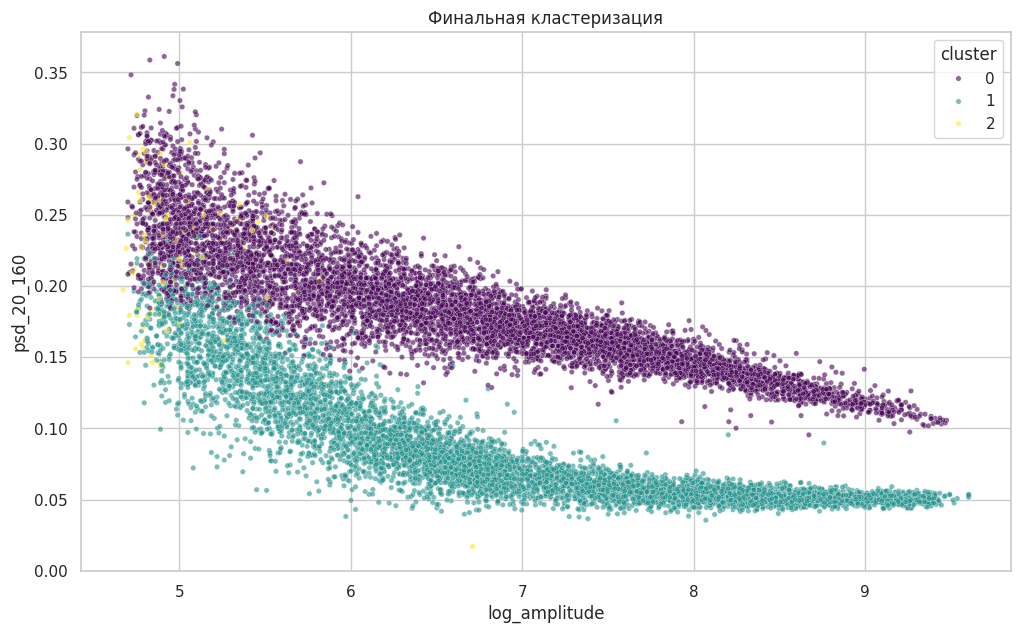

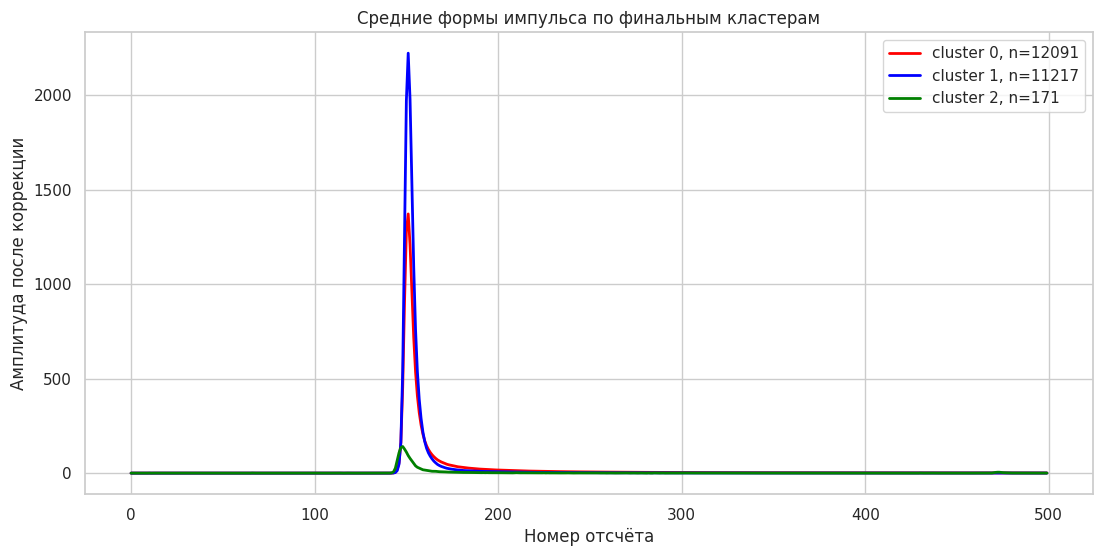

In [24]:
plot_final = features.sample(n=min(14000, len(features)), random_state=RANDOM_STATE)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_final,
    x="log_amplitude",
    y="psd_20_160",
    hue="cluster",
    palette="viridis",
    s=15,
    alpha=0.60,
)
plt.title("Финальная кластеризация")
plt.xlabel("log_amplitude")
plt.ylabel("psd_20_160")
plt.legend(title="cluster")
plt.show()

plt.figure(figsize=(13, 6))
for cluster_id in sorted(np.unique(final_labels)):
    idx = np.flatnonzero(final_labels == cluster_id)
    if idx.size == 0:
        continue
    idx_sample = idx[: min(5000, idx.size)]
    mean_curve = pulses[idx_sample].mean(axis=0)
    plt.plot(mean_curve, linewidth=2, label=f"cluster {cluster_id}, n={idx.size}")
plt.title("Средние формы импульса по финальным кластерам")
plt.xlabel("Номер отсчёта")
plt.ylabel("Амплитуда после коррекции")
plt.legend()
plt.show()


,feature,importance
2,psd_20_160,0.244587
1,log_amplitude,0.224495
0,log_q_total_160,0.205402
3,psd_30_160,0.184317
4,psd_40_160,0.141199


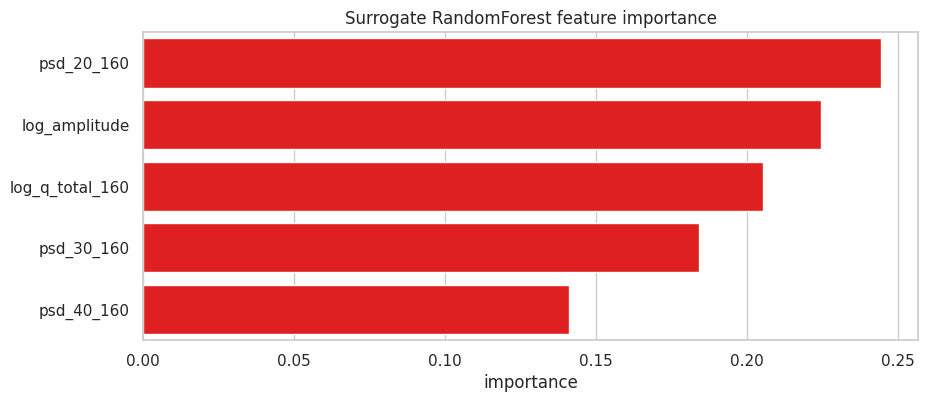

In [25]:
importance_cols = kept_features[best_feature_set]
x_importance = features[importance_cols].replace([np.inf, -np.inf], np.nan)
x_importance = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(x_importance),
    columns=importance_cols,
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(x_importance, final_labels)

importance = pd.DataFrame(
    {
        "feature": importance_cols,
        "importance": rf.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(importance)

plt.figure(figsize=(10, max(4, 0.35 * len(importance))))
sns.barplot(data=importance, y="feature", x="importance")
plt.title("Surrogate RandomForest feature importance")
plt.xlabel("importance")
plt.ylabel("")
plt.show()

Наибольшую важность получил признак psd_20_160 — 0.2446. Это означает, что доля хвостовой части импульса после первых 20 отсчётов является наиболее информативной для разделения сигналов. Вторым по значимости оказался признак log_amplitude с importance 0.2245. Он отражает амплитуду сигнала в логарифмическом масштабе.

В ходе работы была решена задача автоматической кластеризации сигналов сцинтилляционного детектора. Исходный датасет содержит 23 479 сигналов, каждый из которых представлен осциллограммой длиной 500 отсчётов. На этапе первичного анализа было установлено, что сигналы имеют стабильную базовую линию и отрицательную ориентацию импульса, поэтому перед извлечением признаков была выполнена коррекция baseline и инверсия сигнала.

Для каждого события были рассчитаны такие признаки как амплитуда, интегральные характеристики, логарифм полного заряда, PSD-признаки, временное положение пика, ширина импульса, отношение сигнала и шума и индикаторы возможных аномалий. Проверка качества признаков показала отсутствие пропущенных значений, константных признаков и дубликатов feature-векторов.

EDA показала, что наиболее информативная структура данных проявляется на PSD-графиках, где по одной оси откладывается энергетическая характеристика сигнала, а по другой — доля хвостовой части импульса. Такой подход соответствует физическому смыслу задачи, поскольку различные типы частиц могут отличаться формой затухания сцинтилляционного импульса.

Для сравнения были обучены несколько базовых моделей кластеризации: KMeans, MiniBatchKMeans, Gaussian Mixture Model, Birch, а также гибридный подход IsolationForest и GMM. Лучший baseline по внутренним метрикам показала модель MiniBatchKMeans на наборе признаков core_psd. Однако базовые модели склонны делить данные на три сравнительно крупных кластера, что не полностью соответствует постановке задачи, где третий класс должен отражать скорее аномальные сигналы.

Поэтому финальное решение было построено на основе локальной PSD-границы. Данные были рассмотрены в пространстве log_q_total_160 — psd_30_160. В разных диапазонах энергии с помощью Gaussian Mixture Model определялась локальная граница между двумя основными PSD-ветвями. Дополнительно выделялись явно нестандартные события: сигналы с поздним пиком, низким зарядом, низким отношением сигнал/шум или нетипичной шириной импульса. Эти объекты были отнесены к классу 2.

Финальное распределение классов составило: 12091 сигнал в классе 0, 11217 сигналов в классе 1 и 171 сигнал в классе 2. Таким образом, две основные группы имеют сопоставимый размер, а третий класс содержит небольшое количество нетипичных событий, что соответствует физической интерпретации задачи.

Анализ важности признаков с помощью суррогатной модели RandomForest показал, что наибольший вклад в объяснение финального разбиения вносят PSD-признаки, логарифм амплитуды и логарифм полного заряда.

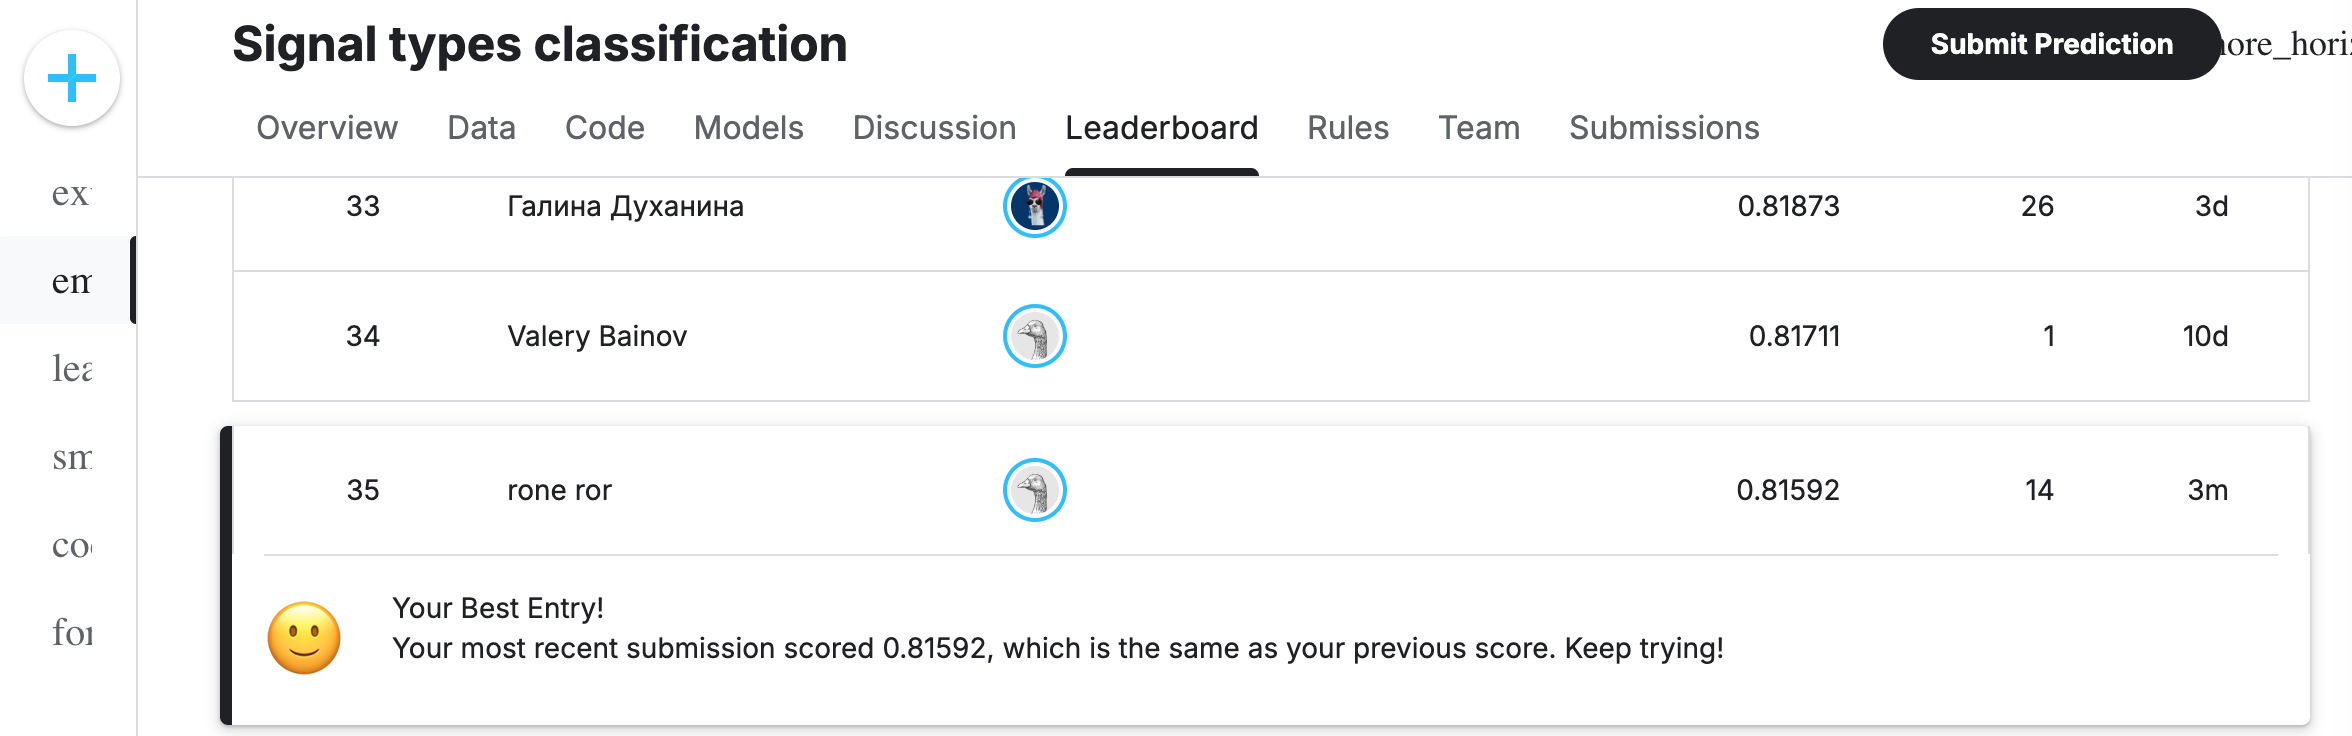